In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

# Data Cleaning

In [3]:
df = pd.read_csv('movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
df.shape

(7668, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [6]:
df.nunique()

name        7512
rating        12
genre         19
year          41
released    3414
score         72
votes        936
director    2949
writer      4535
star        2814
country       59
budget       413
gross       7472
company     2385
runtime      138
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
(df.isna().sum()/len(df))*100

name         0.000000
rating       1.004173
genre        0.000000
year         0.000000
released     0.026082
score        0.039124
votes        0.039124
director     0.000000
writer       0.039124
star         0.013041
country      0.039124
budget      28.312467
gross        2.464789
company      0.221701
runtime      0.052165
dtype: float64

In [9]:
df.dropna(subset=['rating', 'released', 'score', 'votes', 'writer', 'star', 'country', 'gross', 'company', 'runtime'], inplace=True)

In [10]:
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
df['budget'].describe()

count         5,421
mean     36,009,170
std      41,573,374
min           6,000
25%      10,000,000
50%      21,800,000
75%      45,000,000
max     356,000,000
Name: budget, dtype: float64

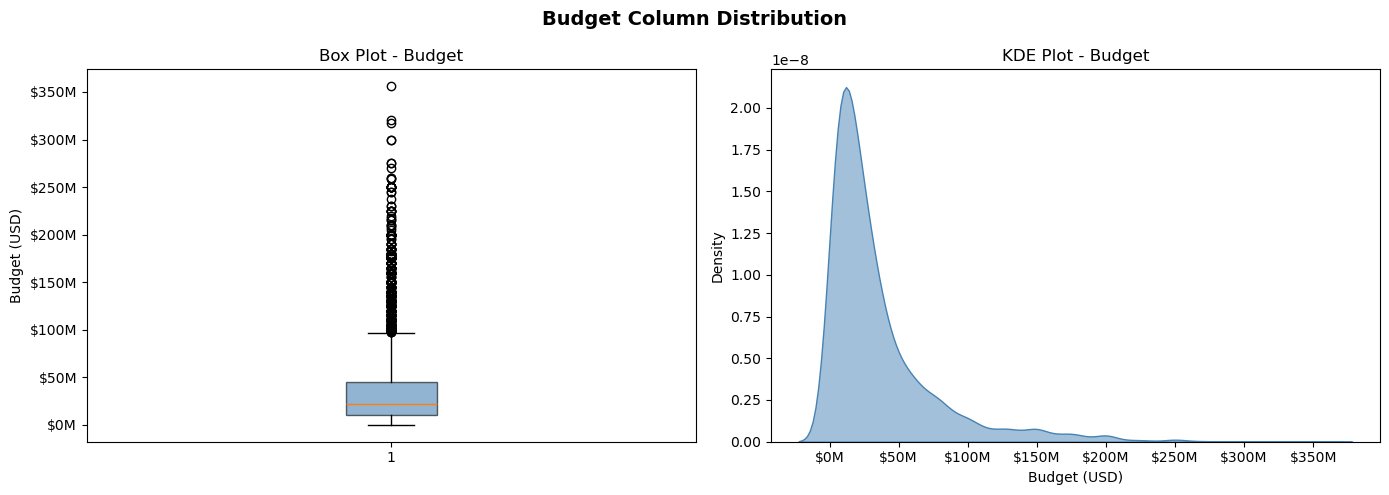

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Budget Column Distribution', fontsize=14, fontweight='bold')

# Box plot
axes[0].boxplot(df['budget'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Box Plot - Budget')
axes[0].set_ylabel('Budget (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# KDE plot
sns.kdeplot(df['budget'].dropna(), ax=axes[1], fill=True, color='steelblue', alpha=0.5)
axes[1].set_title('KDE Plot - Budget')
axes[1].set_xlabel('Budget (USD)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

In [12]:
df['budget'].skew()

np.float64(2.44338135130822)

In [13]:
df['budget'] = df.groupby('genre')['budget'].transform(lambda x: x.fillna(x.median()))

In [19]:
(df.isna().sum() / len(df) * 100).round(5)  

name       0
rating     0
genre      0
year       0
released   0
score      0
votes      0
director   0
writer     0
star       0
country    0
budget     0
gross      0
company    0
runtime    0
dtype: float64

In [23]:
for col in df.columns:
        null_count = df[col].isnull().sum()
        null_pct   = (null_count / len(df)) * 100
        dtype      = df[col].dtype
        
        print(f"{col:<15} nulls: {null_count:<6} ")


name            nulls: 0      
rating          nulls: 0      
genre           nulls: 0      
year            nulls: 0      
released        nulls: 0      
score           nulls: 0      
votes           nulls: 0      
director        nulls: 0      
writer          nulls: 0      
star            nulls: 0      
country         nulls: 0      
budget          nulls: 3      
gross           nulls: 0      
company         nulls: 0      
runtime         nulls: 0      


In [24]:
# 3 rows in budget weren't filled by genre median
# fill remaining with global median
df['budget'].fillna(df['budget'].median(), inplace=True)

# now confirm


df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['votes'] = df['votes'].astype('int64')
df['runtime'] = df['runtime'].astype('int64')

In [25]:
#Correct Year Column

df['yearcorrect'] = df['released'].str.extract(r'(\d{4})')

In [26]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",6,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",9,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",8,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98,1980


In [27]:
df = df.sort_values(by = ['gross'], inplace = False, ascending = False)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018


# Correlation Analysis
Highest Correlation to gross earning.  

In this section, our focus is to find the highest correlation with gross earning. For this purpose we will make the correlation matrix, and find the the highest correlation. The pearson methods is used here.

In [33]:
pd.reset_option('display.float_format')
df.corr(numeric_only=True, method='pearson')

,year,score,votes,budget,gross,runtime
year,1.000000,0.093951,0.218941,0.293453,0.258826,0.114237
score,0.093951,1.000000,0.415190,0.058697,0.188071,0.397226
votes,0.218941,0.415190,1.000000,0.452275,0.631110,0.309945
budget,0.293453,0.058697,0.452275,1.000000,0.738224,0.264866
gross,0.258826,0.188071,0.631110,0.738224,1.000000,0.245117
runtime,0.114237,0.397226,0.309945,0.264866,0.245117,1.000000


In [49]:
pd.reset_option('display.float_format')
df.corr(numeric_only=True, method='spearman')

,year,score,votes,budget,gross,runtime
year,1.000000,0.095848,0.465166,0.264284,0.297499,0.133069
score,0.095848,1.000000,0.434803,-0.020125,0.129759,0.398280
votes,0.465166,0.434803,1.000000,0.402329,0.743122,0.281526
budget,0.264284,-0.020125,0.402329,1.000000,0.558910,0.258820
gross,0.297499,0.129759,0.743122,0.558910,1.000000,0.246503
runtime,0.133069,0.398280,0.281526,0.258820,0.246503,1.000000


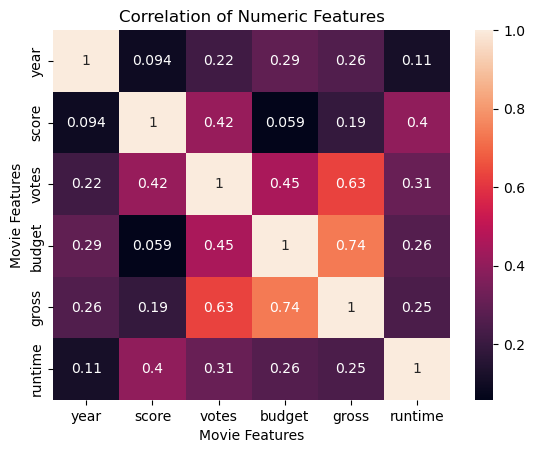

In [34]:
correlation_matrix = df.corr(numeric_only=True, method = 'pearson') 
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation of Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

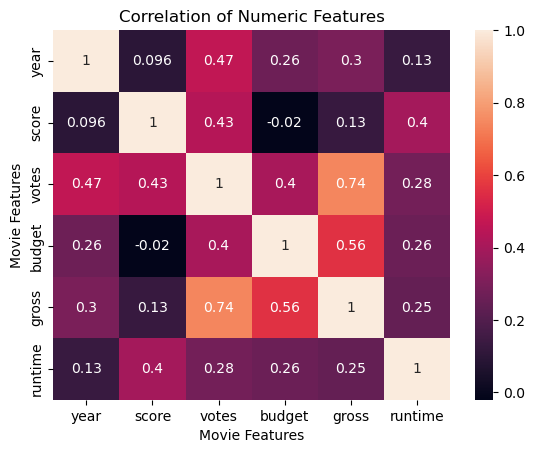

In [51]:
correlation_matrix = df.corr(numeric_only=True, method = 'spearman') 
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation of Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

#### We observe that 'votes' and 'budget' is highly correlated but both method give different correlation coefficient so we have to see which shows correct correlation.

### Correlation Between Budget VS Gross

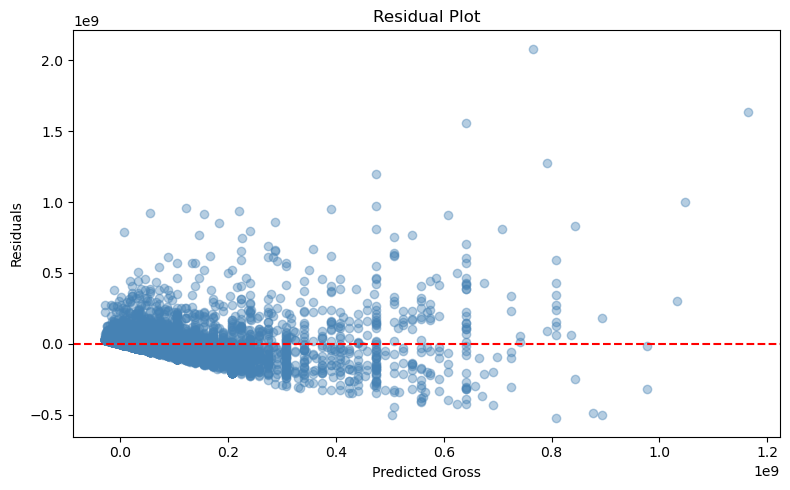

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# fit a linear regression line
coeffs = np.polyfit(df['budget'], df['gross'], 1)
predicted = np.polyval(coeffs, df['budget'])

# calculate residuals
residuals = df['gross'] - predicted

# residual plot only
plt.figure(figsize=(8, 5))
plt.scatter(predicted, residuals, alpha=0.4, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot')
plt.xlabel('Predicted Gross')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import shapiro

stat, p_value = shapiro(df['budget'].dropna())

print(f'Stat    : {stat:.4f}')
print(f'P-value : {p_value:.5f}')

if p_value > 0.05:
    print('Result  : Normally distributed ✅ → Use Pearson')
else:
    print('Result  : Not normally distributed ❌ → Use Spearman')

Stat    : 0.6789
P-value : 0.00000
Result  : Not normally distributed ❌ → Use Spearman


- Budget is not normalyy distributed.
- Budget has outlier.
- From residual plot we can conclude that relationship between Budget and Gross is not linear
- From above statement we can conclude that we should use spearman correlation for these columns.

In [39]:
# spearman correlation matrix
corr_matrix = df[['budget', 'gross']].corr(method='spearman')

print(corr_matrix)

         budget    gross
budget  1.00000  0.55891
gross   0.55891  1.00000


### Correlation Between Votes and Gross

In [48]:
pd.reset_option('display.float_format')
df.corr(numeric_only=True, method='pearson')

,year,score,votes,budget,gross,runtime
year,1.000000,0.093951,0.218941,0.293453,0.258826,0.114237
score,0.093951,1.000000,0.415190,0.058697,0.188071,0.397226
votes,0.218941,0.415190,1.000000,0.452275,0.631110,0.309945
budget,0.293453,0.058697,0.452275,1.000000,0.738224,0.264866
gross,0.258826,0.188071,0.631110,0.738224,1.000000,0.245117
runtime,0.114237,0.397226,0.309945,0.264866,0.245117,1.000000


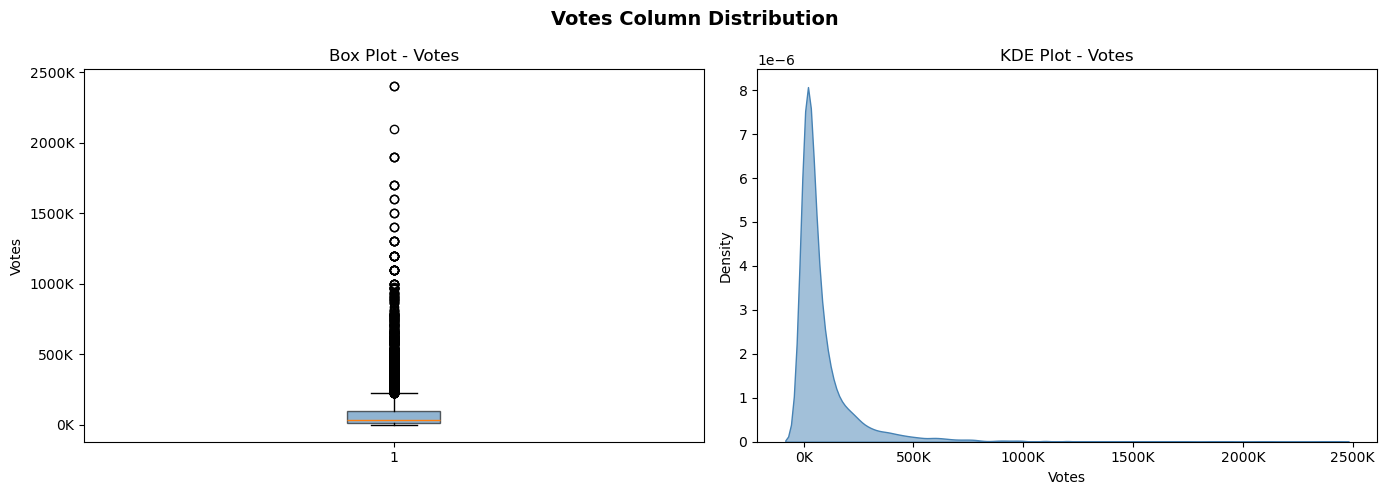

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Votes Column Distribution', fontsize=14, fontweight='bold')

# Box plot
axes[0].boxplot(df['votes'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Box Plot - Votes')
axes[0].set_ylabel('Votes')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# KDE plot
sns.kdeplot(df['votes'].dropna(), ax=axes[1], fill=True, color='steelblue', alpha=0.5)
axes[1].set_title('KDE Plot - Votes')
axes[1].set_xlabel('Votes')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

In [43]:
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
df['votes'].describe()

count       7,412
mean       90,764
std       165,347
min           105
25%        10,000
50%        34,000
75%        96,000
max     2,400,000
Name: votes, dtype: float64

In [44]:
from scipy.stats import shapiro

stat, p_value = shapiro(df['votes'].dropna())

print(f'Stat    : {stat:.4f}')
print(f'P-value : {p_value:.5f}')

if p_value > 0.05:
    print('Result  : Normally distributed ✅ → Use Pearson')
else:
    print('Result  : Not normally distributed ❌ → Use Spearman')

Stat    : 0.5267
P-value : 0.00000
Result  : Not normally distributed ❌ → Use Spearman


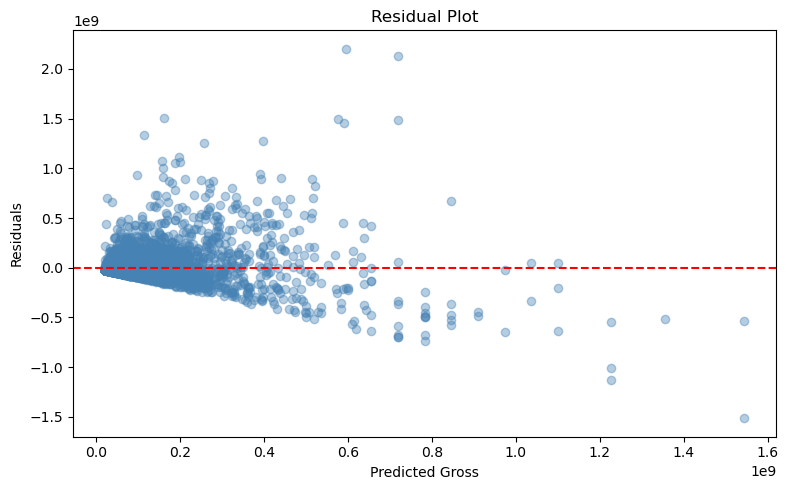

In [45]:
# fit a linear regression line
coeffs = np.polyfit(df['votes'], df['gross'], 1)
predicted = np.polyval(coeffs, df['votes'])

# calculate residuals
residuals = df['gross'] - predicted

# residual plot only
plt.figure(figsize=(8, 5))
plt.scatter(predicted, residuals, alpha=0.4, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot')
plt.xlabel('Predicted Gross')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

- votes is not normalyy distributed.
- votes has outlier.
- From residual plot we can conclude that relationship between Budget and votes is not linear
- From above statement we can conclude that we should use spearman correlation for these columns.

In [50]:
# spearman correlation matrix
pd.reset_option('display.float_format')
corr_matrix = df[['gross', 'votes']].corr(method='spearman')

print(corr_matrix)

          gross     votes
gross  1.000000  0.743122
votes  0.743122  1.000000


### Results
- The correlation between 'budget' and 'gross' is **0.55** which is moderately correlated.
- The correlation between 'budget' and 'votes' is **0.40** which is moderately correlated.


# Conclusion

Our project involved cleaning and analyzing a movie dataset.The main conclusion is that 'budget' and 'votes' have the highest correlations to gross earnings. Both have a positive correlation: as movie's budget and audience ratings increase, gross earnings tend to increase as well.These insights can be valuable for decision-making in the movie industry, as they highlight factors that significantly influence box office success.